In [ ]:
import os
gdrive_root = '/drive/content'

In [ ]:
!pip install --upgrade git+https://github.com/pyushkevich/upenn_be5370_utils.git

  Cloning https://github.com/pyushkevich/upenn_be5370_utils.git to /tmp/pip-req-build-b6u1gh23
  Running command git clone --filter=blob:none --quiet https://github.com/pyushkevich/upenn_be5370_utils.git /tmp/pip-req-build-b6u1gh23
  Resolved https://github.com/pyushkevich/upenn_be5370_utils.git to commit 801c634d57f426a21c3a23762c332bdef43459a8
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 22.5 MB/s eta 0:00:00
  Created wheel for upenn_be5370_utils: filename=upenn_be5370_utils-0.2-py3-none-any.whl size=11259 sha256=c616f695a8c4c67c6d2c9507a346e95bc716b84d48c50fed8e15931318761ad6
  Stored in directory: /tmp/pip-ephem-wheel-cache-i_w5o3y5/wheels/db/a8/d2/9e840877c2229dcd0d9c6e480b8829849c2ad13628794b0f75
Successfully built upenn_be5370_utils


Import the utilities package

In [ ]:
from upenn_be5370_utils import sitkview

### Install nnU-Net and create the directory structure

clone the nnUNet repository into a subfolder. We install it on your Drive instead of locally on the runtime in order to make it possible to modify nnUNet code. It will then install nnUNet on the runtime in edit mode `-e`, so that the changes you make to the code are immediately accessible to you in the notebook.

In [ ]:
os.environ['NNUNET_REPO']=os.path.join(gdrive_root, 'nnUNet')

!if [[ ! -d $NNUNET_REPO ]]; then git clone https://github.com/MIC-DKFZ/nnUNet.git $NNUNET_REPO; fi

!cd $NNUNET_REPO && pip install -e .

!pip install --upgrade git+https://github.com/FabianIsensee/hiddenlayer.git

Obtaining file:///content/drive/MyDrive/be5370_hw1/colab_data/nnUNet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.1 MB/s eta 0:00:00
  Building editable for nnunetv2 (pyproject.toml) ... done
  Created wh

In [ ]:
for d in ['nnUNet_raw','nnUNet_preprocessed','nnUNet_results']:
  d_fullpath = os.path.join(gdrive_root, d)
  os.makedirs(d_fullpath, exist_ok=True)
  os.environ[d] = d_fullpath
  print(f'Setting {d}={d_fullpath}')

Setting nnUNet_raw=/content/drive/MyDrive/be5370_hw1/colab_data/nnUNet_raw
Setting nnUNet_preprocessed=/content/drive/MyDrive/be5370_hw1/colab_data/nnUNet_preprocessed
Setting nnUNet_results=/content/drive/MyDrive/be5370_hw1/colab_data/nnUNet_results


# Step 1-B

# Parameter Evaluation Plan
1. **Control Points Parameters (B-spline Grid)**
* Definition: The control_points_params set the B-spline grid size at each multi-resolution N4 iteration, with each element specifying the number of control points in x, y, and z for that level. These grids determine the flexibility of the estimated bias field for each resolution pass (from coarse to fine) .
* Reasons: Finer control point grids (e.g., ) allow the bias correction to model rapid intensity variations and can adapt to more localized artifacts, which is increasingly important with modern MRI hardware. However, excessively fine grids may introduce overfitting, risk removing anatomical contrast, or amplify noise. The multi-resolution approach aids in robust estimation—progressively refining the correction while preserving critical gradients like gray–white matter boundaries.
* Range: Staged control point grids = {4,8,12,16,20}, typically progressing from coarsest to finest. This covers a spectrum from very smooth bias fields (low spatial frequency) to more detailed corrections at higher frequencies. The default was 4 and we started at 8 because the number of control points should be greater than the spline order, so 2 would not have worked.
2. **Iteration Parameters (Per Level Iterations)**
* Definition: iteration_params specifies the number of correction iterations at each multi-resolution level in N4, controlling convergence rigor at each spatial scale.
* Reasons: More iterations allow greater opportunity to fit and refine the bias estimate at each resolution, improving correction accuracy—but can increase computation time and possibly lead to diminishing returns if over-iterated. A staged approach (30 → 50 → 80 → 110) helps ensure adequate fitting at both coarse and fine grids.
* Range: 30 (coarsest), 50(default), 80, and 110 (finest) iterations per level, balancing robustness and performance.



# Step 1-C

In [ ]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from upenn_be5370_utils.sitkview import view_hemi

# Step 1-D

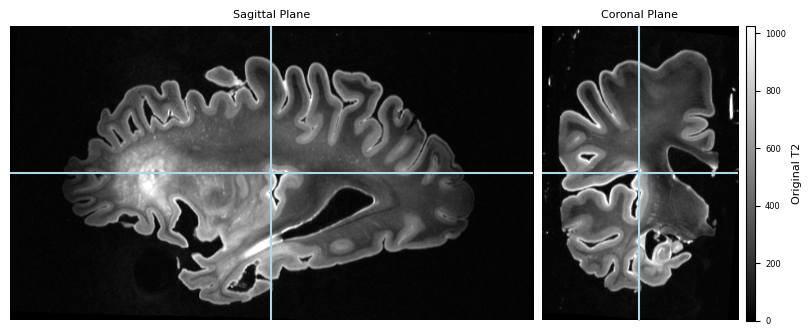

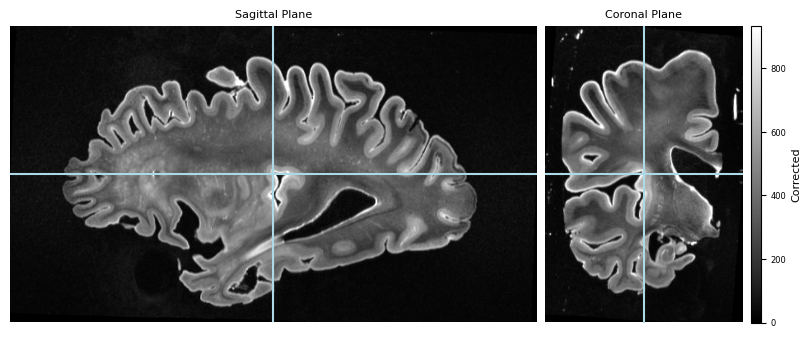

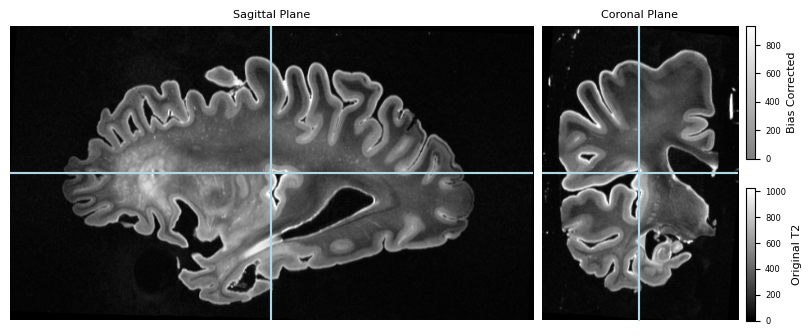

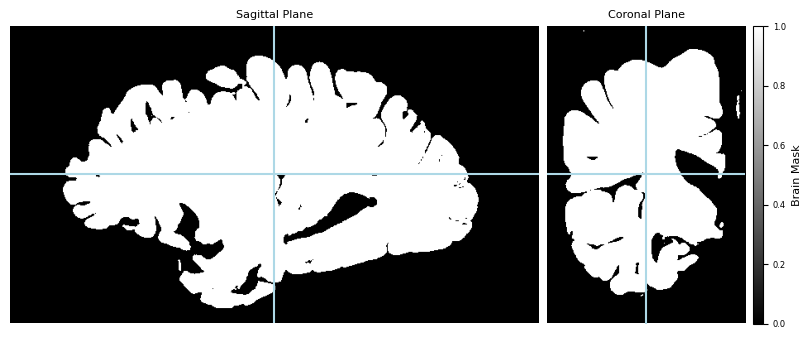

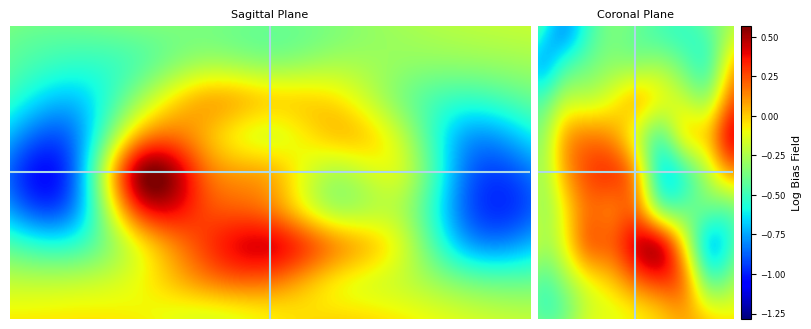

In [ ]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
from upenn_be5370_utils.sitkview import view_hemi

def run_n4_bias_correction(t2_path, ciss_path):
    t2 = sitk.ReadImage(t2_path)
    ciss = sitk.ReadImage(ciss_path)

    #brain mask
    mask = sitk.OtsuThreshold(ciss, 0, 1, 200)

    #implementing Gaussian smoothing to T2 (sigma=1.0)
    smoothed = sitk.SmoothingRecursiveGaussian(t2, 1.0)

    # downsampling (2x)
    shrink_factor = 2
    smoothed_ds = sitk.Shrink(smoothed, [shrink_factor]*3)
    mask_ds = sitk.BinShrink(mask, [shrink_factor]*3)

    n4 = sitk.N4BiasFieldCorrectionImageFilter()

    #N4 algorithm
    corrected_ds = n4.Execute(smoothed_ds, mask_ds)

    #bias field (log scale)
    log_bias_field = n4.GetLogBiasFieldAsImage(smoothed_ds)

    #upsample to implement bias field to original image
    log_bias_field_up = sitk.Resample(log_bias_field, t2, sitk.Transform(), sitk.sitkLinear, 0.0, log_bias_field.GetPixelID())

    t2_float = sitk.Cast(t2, sitk.sitkFloat32)

    #calculate corrected image (og T2 - corrected)
    corrected = sitk.Exp(sitk.Log(t2_float) - log_bias_field_up)

    #visualization - before after correcting T2 image, mask, bias field
    view_hemi(t2, cmap = "gray", name = "Original T2")
    view_hemi(corrected, cmap = "gray", name = "Corrected")

    view_hemi([t2, corrected], cmap=['gray', 'gray'], alpha=0.5, name=['Original T2', 'Bias Corrected'])
    view_hemi(mask, cmap='gray', name='Brain Mask')
    view_hemi(log_bias_field_up, cmap='jet', name='Log Bias Field')

    return corrected

t2_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_005_t2.nii.gz'
ciss_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_005_ciss.nii.gz'

corrected_image = run_n4_bias_correction(t2_path, ciss_path)


# step 1-E

In [ ]:
# Parameters
control_points_params = [[8,8,8], [12,12,12],[16,16,16], [20,20,20]]
iteration_params      = [30, 50, 80, 110]


#labels
LABEL_BG = 0
LABEL_GM = 1
LABEL_WM = 2


def cohens_d(mu_a, sd_a, mu_b, sd_b):
   return abs(mu_a - mu_b) / np.sqrt(sd_a**2 + sd_b**2 + 1e-12)


def masked_stats(arr, mask):
   vox = arr[mask]
   if vox.size == 0:
       return np.nan, np.nan
   return float(vox.mean()), float(vox.std())


def wm_gm_cohens_d(corrected, seg_img):
   arr = sitk.GetArrayFromImage(corrected)
   seg = sitk.GetArrayFromImage(seg_img)


   wm = seg == LABEL_WM
   gm = seg == LABEL_GM


   mu_wm, sd_wm = masked_stats(arr, wm)
   mu_gm, sd_gm = masked_stats(arr, gm)


   return cohens_d(mu_wm, sd_wm, mu_gm, sd_gm)


def run_n4_bias_correction(t2_path, ciss_path, control_points=[8,8,8], max_iter=50, shrink_factor=4):
   t2 = sitk.ReadImage(t2_path)
   ciss = sitk.ReadImage(ciss_path)


   mask = sitk.OtsuThreshold(ciss, 0, 1, 200)
   smoothed = sitk.SmoothingRecursiveGaussian(t2, 1.0)
   smoothed_ds = sitk.Shrink(smoothed, [shrink_factor]*3)
   mask_ds     = sitk.BinShrink(mask, [shrink_factor]*3)


   n4 = sitk.N4BiasFieldCorrectionImageFilter()
   n4.SetNumberOfControlPoints(control_points)
   n4.SetMaximumNumberOfIterations([max_iter])


   corrected_ds = n4.Execute(smoothed_ds, mask_ds)
   log_bias_field = n4.GetLogBiasFieldAsImage(smoothed_ds)
   log_bias_field_up = sitk.Resample(log_bias_field, t2, sitk.Transform(),
                                     sitk.sitkLinear, 0.0, log_bias_field.GetPixelID())


   t2_float = sitk.Cast(t2, sitk.sitkFloat32)
   corrected = sitk.Exp(sitk.Log(t2_float) - log_bias_field_up)
   return corrected


#Run
t2_path   = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_006_t2.nii.gz'
ciss_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_006_ciss.nii.gz'
seg_path  = '/content/drive/MyDrive/be5370_hw1/subj_006_t2_n4sam.nii.gz'
seg_img   = sitk.ReadImage(seg_path)


results = []


for ctrl in control_points_params:
   for it in iteration_params:
       print(f"Running N4 with control_points={ctrl}, iterations={it}")
       corrected = run_n4_bias_correction(t2_path, ciss_path,
                                          control_points=ctrl,
                                          max_iter=it)


       d_val = wm_gm_cohens_d(corrected, seg_img)


       results.append({
           "control_points": str(ctrl),
           "iterations": it,
           "d_WM_GM": d_val
       })


#####
df = pd.DataFrame(results)
print(df)





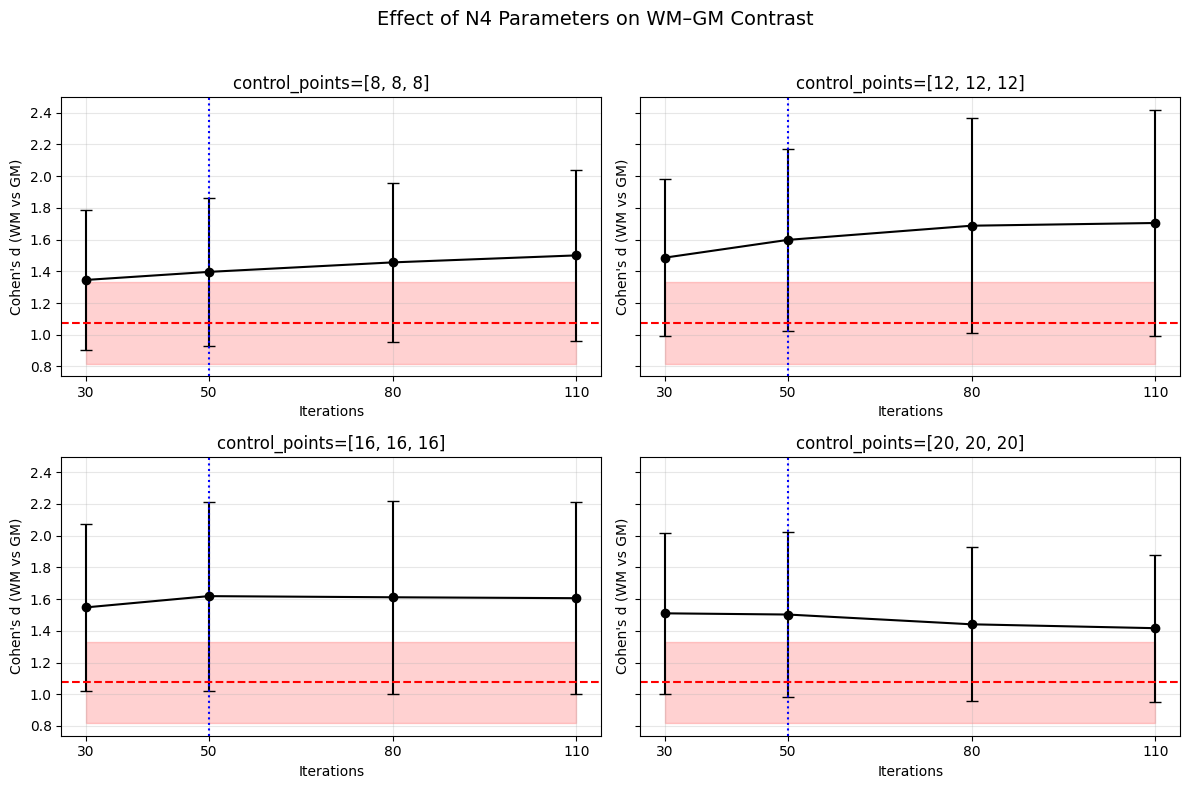

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = {
   "control_points": [
       [8,8,8],[8,8,8],[8,8,8],[8,8,8],
       [12,12,12],[12,12,12],[12,12,12],[12,12,12],
       [16,16,16],[16,16,16],[16,16,16],[16,16,16],
       [20,20,20],[20,20,20],[20,20,20],[20,20,20]
   ],
   "iterations": [30,50,80,110]*4,
   "d_WM_GM_001": [2.041148,2.115175,2.208717,2.285656,2.22601,2.368309,2.455021,2.470206,
                   2.278163,2.360154,2.329123,2.307633,2.243115,2.222651,2.087746,2.00333],
   "d_WM_GM_002": [1.425724,1.546694,1.693036,1.830707,1.661359,2.03872,2.473518,2.603237,
                   1.836038,2.173565,2.251429,2.259634,1.737286,1.882119,1.84655,1.85355],
   "d_WM_GM_003": [0.73669,0.735137,0.738737,0.738737,0.75571,0.765712,0.771364,0.771046,
                   0.757954,0.761549,0.743637,0.742964,0.764146,0.751999,0.729967,0.729967],
   "d_WM_GM_004": [1.209449664,1.235621133,1.269305753,1.28567627,1.327987044,1.338024973,1.333429574,1.332150595,
                   1.343696315,1.333388727,1.317224143,1.315281682,1.328965454,1.286134108,1.239823582,1.239823582],
   "d_WM_GM_005": [1.122045,1.169354,1.213304,1.222396,1.265623,1.319996,1.33995,1.33995,
                   1.31107,1.333193,1.33903,1.33903,1.255441,1.229138,1.220589,1.220589],
   "d_WM_GM_006": [1.53873239,1.576363987,1.614816939,1.639855511,1.680811786,1.7576616,1.752570882,1.712002789,
                   1.759625881,1.750489572,1.689054965,1.670229739,1.732986534,1.644682231,1.522106885,1.452626377]
}
df = pd.DataFrame(data)


cols = [c for c in df.columns if c.startswith("d_WM_GM_")]
df["mean_d"] = df[cols].mean(axis=1)
df["std_d"]  = df[cols].std(axis=1)


# no N4
baseline_mean = 1.074492506
baseline_std  = 0.2559328343


df["iterations"] = df["iterations"].astype(int)
df["cp_tuple"] = df["control_points"].apply(lambda x: tuple(x))  # list -> tuple


baseline_mean = 1.074492506
baseline_std  = 0.2559328343


control_sets = [(8,8,8), (12,12,12), (16,16,16), (20,20,20)]


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)


for ax, ctrl in zip(axes.flatten(), control_sets):
   sub = df[df["cp_tuple"] == ctrl].sort_values("iterations")


   #mean ± sd
   ax.errorbar(sub["iterations"], sub["mean_d"], yerr=sub["std_d"],
               fmt="o-", color="black", ecolor="black", capsize=4)


   #red dashed baseline (no N4) + shaded band (±1 SD) spanning the panel
   xlo, xhi = sub["iterations"].min(), sub["iterations"].max()
   ax.axhline(baseline_mean, color="red", linestyle="--", linewidth=1.5)
   ax.fill_between([xlo, xhi],
                   baseline_mean - baseline_std,
                   baseline_mean + baseline_std,
                   color="red", alpha=0.18)


   #blue vertical line at default iterations = 50
   ax.axvline(50, color="blue", linestyle=":", linewidth=1.5)


   ax.set_title(f"control_points={list(ctrl)}")
   ax.set_xlabel("Iterations")
   ax.set_ylabel("Cohen's d (WM vs GM)")
   ax.set_xticks(sub["iterations"])
   ax.grid(True, alpha=0.3)


fig.suptitle("Effect of N4 Parameters on WM–GM Contrast", fontsize=14)
fig.tight_layout(rect=[0,0,1,0.96])
plt.show()

We perform different iterations (30, 50, 80, 110) for 4 different control point grids ([8, 8, 8], [12, 12, 12], [16, 16, 16], [20, 20, 20]), and plot 4 different plots for each control point.
Overall, N4 bias correction improved WM–GM contrast across all tested settings compared to baseline. Intermediate control point grids ([12,12,12] and [16,16,16]) gave the most consistent gains, while very coarse ([8,8,8]) or fine ([20,20,20]) grids were less effective. Increasing iterations modestly improved contrast up to ~80 iterations, after which improvements plateaued. The best overall performance was observed at [12,12,12] with 80–110 iterations, though with higher variability across subjects. The error bars highlight that not all subjects benefited equally. For example, subjects such as subj_001 and subj_006 contributed disproportionately to the spread, which may reflect differences in initial bias field severity.


#compare 2 hemisphere

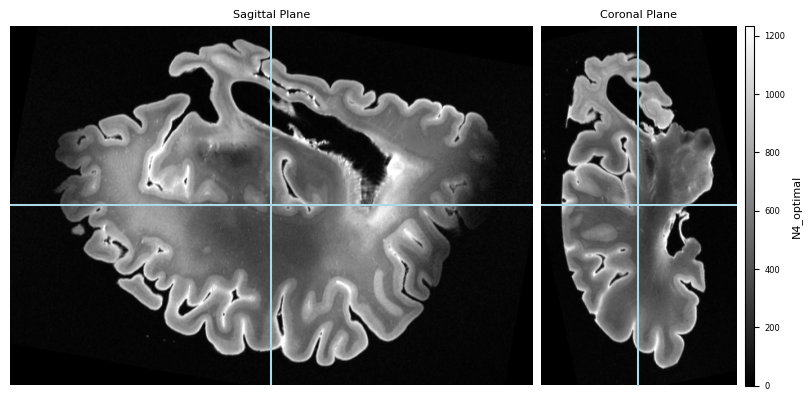

In [ ]:
def run_n4_bias_correction(t2_path, ciss_path):
    t2 = sitk.ReadImage(t2_path)
    ciss = sitk.ReadImage(ciss_path)

    #brain mask
    mask = sitk.OtsuThreshold(ciss, 0, 1, 200)

    #implementing Gaussian smoothing to T2 (sigma=1.0)
    smoothed = sitk.SmoothingRecursiveGaussian(t2, 1.0)

    # downsampling (2x)
    shrink_factor = 2
    smoothed_ds = sitk.Shrink(smoothed, [shrink_factor]*3)
    mask_ds = sitk.BinShrink(mask, [shrink_factor]*3)

    n4 = sitk.N4BiasFieldCorrectionImageFilter()
    n4.SetNumberOfControlPoints([8,8,8])
    n4.SetMaximumNumberOfIterations([110])

    #N4 algorithm
    corrected_ds = n4.Execute(smoothed_ds, mask_ds)

    #bias field (log scale)
    log_bias_field = n4.GetLogBiasFieldAsImage(smoothed_ds)

    #upsample to implement bias field to original image
    log_bias_field_up = sitk.Resample(log_bias_field, t2, sitk.Transform(), sitk.sitkLinear, 0.0, log_bias_field.GetPixelID())

    t2_float = sitk.Cast(t2, sitk.sitkFloat32)

    #calculate corrected image (og T2 - corrected)
    corrected = sitk.Exp(sitk.Log(t2_float) - log_bias_field_up)

    #visualization - before after correcting T2 image, mask, bias field
    view_hemi(corrected, cmap='gray', name=['N4_optimal'])

    return corrected

t2_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_009_t2.nii.gz'
ciss_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_009_ciss.nii.gz'

corrected_image = run_n4_bias_correction(t2_path, ciss_path)

# subject 010

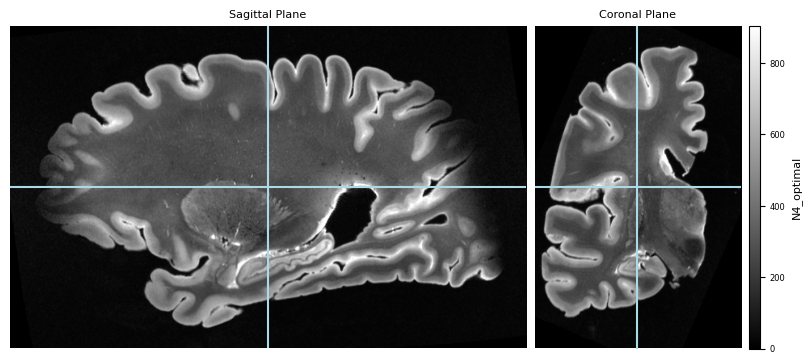

In [ ]:

def run_n4_bias_correction(t2_path, ciss_path):
    t2 = sitk.ReadImage(t2_path)
    ciss = sitk.ReadImage(ciss_path)

    #brain mask
    mask = sitk.OtsuThreshold(ciss, 0, 1, 200)

    #implementing Gaussian smoothing to T2 (sigma=1.0)
    smoothed = sitk.SmoothingRecursiveGaussian(t2, 1.0)

    # downsampling (2x)
    shrink_factor = 2
    smoothed_ds = sitk.Shrink(smoothed, [shrink_factor]*3)
    mask_ds = sitk.BinShrink(mask, [shrink_factor]*3)

    n4 = sitk.N4BiasFieldCorrectionImageFilter()
    n4.SetNumberOfControlPoints([8,8,8])
    n4.SetMaximumNumberOfIterations([110])

    #N4 algorithm
    corrected_ds = n4.Execute(smoothed_ds, mask_ds)

    #bias field (log scale)
    log_bias_field = n4.GetLogBiasFieldAsImage(smoothed_ds)

    #upsample to implement bias field to original image
    log_bias_field_up = sitk.Resample(log_bias_field, t2, sitk.Transform(), sitk.sitkLinear, 0.0, log_bias_field.GetPixelID())

    t2_float = sitk.Cast(t2, sitk.sitkFloat32)

    #calculate corrected image (og T2 - corrected)
    corrected = sitk.Exp(sitk.Log(t2_float) - log_bias_field_up)

    #visualization - before after correcting T2 image, mask, bias field
    view_hemi(corrected, cmap='gray', name=['N4_optimal'])

    return corrected

t2_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_010_t2.nii.gz'
ciss_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_010_ciss.nii.gz'

corrected_image = run_n4_bias_correction(t2_path, ciss_path)


# phase 2

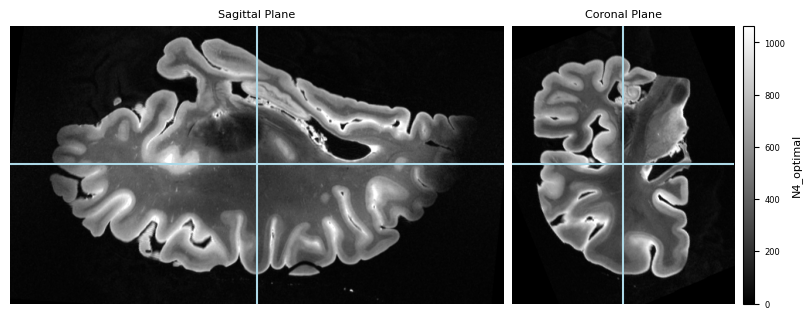

In [ ]:

def run_n4_bias_correction(t2_path, ciss_path):
    t2 = sitk.ReadImage(t2_path)
    ciss = sitk.ReadImage(ciss_path)

    #brain mask
    mask = sitk.OtsuThreshold(ciss, 0, 1, 200)

    #implementing Gaussian smoothing to T2 (sigma=1.0)
    smoothed = sitk.SmoothingRecursiveGaussian(t2, 1.0)

    # downsampling (2x)
    shrink_factor = 2
    smoothed_ds = sitk.Shrink(smoothed, [shrink_factor]*3)
    mask_ds = sitk.BinShrink(mask, [shrink_factor]*3)

    n4 = sitk.N4BiasFieldCorrectionImageFilter()
    n4.SetNumberOfControlPoints([8,8,8])
    n4.SetMaximumNumberOfIterations([110])

    #N4 algorithm
    corrected_ds = n4.Execute(smoothed_ds, mask_ds)

    #bias field (log scale)
    log_bias_field = n4.GetLogBiasFieldAsImage(smoothed_ds)

    #upsample to implement bias field to original image
    log_bias_field_up = sitk.Resample(log_bias_field, t2, sitk.Transform(), sitk.sitkLinear, 0.0, log_bias_field.GetPixelID())

    t2_float = sitk.Cast(t2, sitk.sitkFloat32)

    #calculate corrected image (og T2 - corrected)
    corrected = sitk.Exp(sitk.Log(t2_float) - log_bias_field_up)

    #visualization - before after correcting T2 image, mask, bias field
    view_hemi(corrected, cmap='gray', name=['N4_optimal'])

    return corrected

t2_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_021_t2.nii.gz'
ciss_path = '/content/drive/MyDrive/be5370_hw1/hemi_training/subj_021_ciss.nii.gz'

corrected_image = run_n4_bias_correction(t2_path, ciss_path)


In [ ]:
sitk.WriteImage(corrected_image, "n4_corrected_subj_021.nii.gz")

In [ ]:
import SimpleITK as sitk
import numpy as np
import os
import random

def load_images(t2_path, ciss_path):
    t2_img = sitk.ReadImage(t2_path)
    ciss_img = sitk.ReadImage(ciss_path)
    return t2_img, ciss_img

def compute_brain_mask(t2_img):
    otsu_filter = sitk.OtsuThresholdImageFilter()
    mask = otsu_filter.Execute(t2_img)
    return mask

def is_valid_patch(mask, start_idx, size, existing_patches):
    patch_region = sitk.RegionOfInterest(mask, size, start_idx)
    patch_array = sitk.GetArrayFromImage(patch_region)
    brain_voxel_ratio = np.mean(patch_array > 0)
    if brain_voxel_ratio < 0.5:
        return False
    for ep in existing_patches:
        # Calculate overlap ratio with existing patches
        overlap_min = [max(start_idx[d], ep[d]) for d in range(3)]
        overlap_max = [min(start_idx[d]+size[d], ep[d]+size[d]) for d in range(3)]
        overlap_size = [max(0, overlap_max[d]-overlap_min[d]) for d in range(3)]
        overlap_volume = overlap_size[0]*overlap_size[1]*overlap_size[2]
        patch_volume = size[0]*size[1]*size[2]
        if overlap_volume / patch_volume > 0.2:
            return False
    return True

def extract_and_save_patches(t2_img, ciss_img, mask, out_dir, subj_id, team_id, patch_count=5, patch_size=(64,64,64)):
    np.random.seed(42)
    random.seed(42)
    size = patch_size
    shape = t2_img.GetSize()
    extracted_patches = []
    patches_coords = []

    while len(extracted_patches) < patch_count:
        start_idx = [random.randint(0, shape[d] - size[d]) for d in range(3)]
        if not is_valid_patch(mask, start_idx, size, patches_coords):
            continue

        # Extract patches for T2 and CISS
        t2_patch = sitk.RegionOfInterest(t2_img, size, start_idx)
        ciss_patch = sitk.RegionOfInterest(ciss_img, size, start_idx)

        patch_idx_str = f"{len(extracted_patches):02d}"
        t2_filename = f"subj{subj_id}_team{team_id}_patch{patch_idx_str}_t2_n4.nii.gz"
        ciss_filename = f"subj{subj_id}_team{team_id}_patch{patch_idx_str}_ciss.nii.gz"

        sitk.WriteImage(t2_patch, os.path.join(out_dir, t2_filename))
        sitk.WriteImage(ciss_patch, os.path.join(out_dir, ciss_filename))

        extracted_patches.append((t2_patch, ciss_patch))
        patches_coords.append(start_idx)

    print(f"Extracted and saved {len(extracted_patches)} patches per hemisphere.")

# Example usage:
t2_path = "/content/n4_corrected_subj_021.nii.gz"
ciss_path = "/content/drive/MyDrive/be5370_hw1/hemi_training/subj_021_ciss.nii.gz"
output_directory = "/content/drive/MyDrive/be5370_hw1/patch_output"
subject_id = "021"
team_id = "07"

os.makedirs(output_directory, exist_ok=True)

t2_img, ciss_img = load_images(t2_path, ciss_path)
mask = compute_brain_mask(t2_img)
extract_and_save_patches(t2_img, ciss_img, mask, output_directory, subject_id, team_id)


Extracted and saved 5 patches per hemisphere.


In [ ]:
import SimpleITK as sitk
import numpy as np
import os
import random

def compute_brain_mask(t2_img):
    otsu_filter = sitk.OtsuThresholdImageFilter()
    mask = otsu_filter.Execute(t2_img)
    mask = sitk.Cast(mask > 0, sitk.sitkUInt8)  # ensure binary mask
    return mask

def is_valid_patch(mask, start_idx, size, existing_patches):
    patch_region = sitk.RegionOfInterest(mask, size, start_idx)
    patch_array = sitk.GetArrayFromImage(patch_region)
    brain_voxel_ratio = np.mean(patch_array > 0)

    if brain_voxel_ratio < 0.5:
        return False

    patch_volume = np.prod(size)
    for ep_start in existing_patches:
        overlap_min = [max(start_idx[d], ep_start[d]) for d in range(3)]
        overlap_max = [min(start_idx[d]+size[d], ep_start[d]+size[d]) for d in range(3)]
        overlap_size = [max(0, overlap_max[d]-overlap_min[d]) for d in range(3)]
        overlap_volume = np.prod(overlap_size)
        if overlap_volume / patch_volume > 0.2:
            return False
    return True

def extract_and_save_patches(t2_img, ciss_img, mask, out_dir, subj_id, team_id, patch_count=5, patch_size=(64,64,64)):
    np.random.seed(42)
    random.seed(42)
    size = patch_size
    shape = t2_img.GetSize()
    extracted_patches = []
    patches_coords = []
    attempts = 0

    while len(extracted_patches) < patch_count and attempts < 10000:
        # pick random center, then convert to start_idx
        center = [random.randint(size[d]//2, shape[d] - size[d]//2) for d in range(3)]
        start_idx = [c - size[d]//2 for d, c in enumerate(center)]

        if not is_valid_patch(mask, start_idx, size, patches_coords):
            attempts += 1
            continue

        # Extract patches for T2 and CISS
        t2_patch = sitk.RegionOfInterest(t2_img, size, start_idx)
        ciss_patch = sitk.RegionOfInterest(ciss_img, size, start_idx)

        patch_idx_str = f"{len(extracted_patches):02d}"
        t2_filename = f"subj{subj_id}_team{team_id}_patch{patch_idx_str}_t2_n4.nii.gz"
        ciss_filename = f"subj{subj_id}_team{team_id}_patch{patch_idx_str}_ciss.nii.gz"

        sitk.WriteImage(t2_patch, os.path.join(out_dir, t2_filename))
        sitk.WriteImage(ciss_patch, os.path.join(out_dir, ciss_filename))

        extracted_patches.append((t2_patch, ciss_patch))
        patches_coords.append(start_idx)
        attempts = 0  # reset attempts once success

    print(f"Extracted and saved {len(extracted_patches)} patches for subject {subj_id}, team {team_id}.")

# Example usage:
t2_path = "/content/n4_corrected_subj_018.nii.gz"
ciss_path = "/content/drive/MyDrive/be5370_hw1/hemi_training/subj_018_ciss.nii.gz"
output_directory = "/content/drive/MyDrive/be5370_hw1/patch_output"
subject_id = "018"
team_id = "07"

os.makedirs(output_directory, exist_ok=True)

t2_img, ciss_img = load_images(t2_path, ciss_path)
mask = compute_brain_mask(t2_img)
extract_and_save_patches(t2_img, ciss_img, mask, output_directory, subject_id, team_id)
